<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-21 09:12:39--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.4’

survey-results-publ 100%[===================>] 201.62M  65.7MB/s    in 3.2s    

2026-01-21 09:12:45 (63.5 MB/s) - ‘survey-results-public.sqlite.4’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 189.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 190.9 MB/s eta 0:00:00


In [3]:
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 152.2 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [8]:
# your code goes here
q='''
SELECT CompTotal
FROM main
'''
df=pd.read_sql_query(q,conn)

In [9]:
df.dropna(inplace=True)

<Axes: ylabel='CompTotal'>

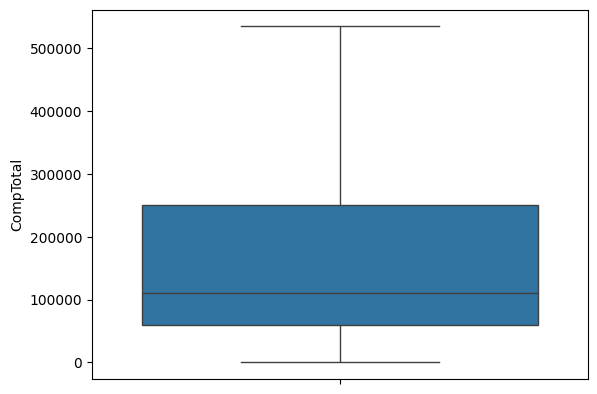

In [10]:
sns.boxplot(df, y='CompTotal', showfliers=False)

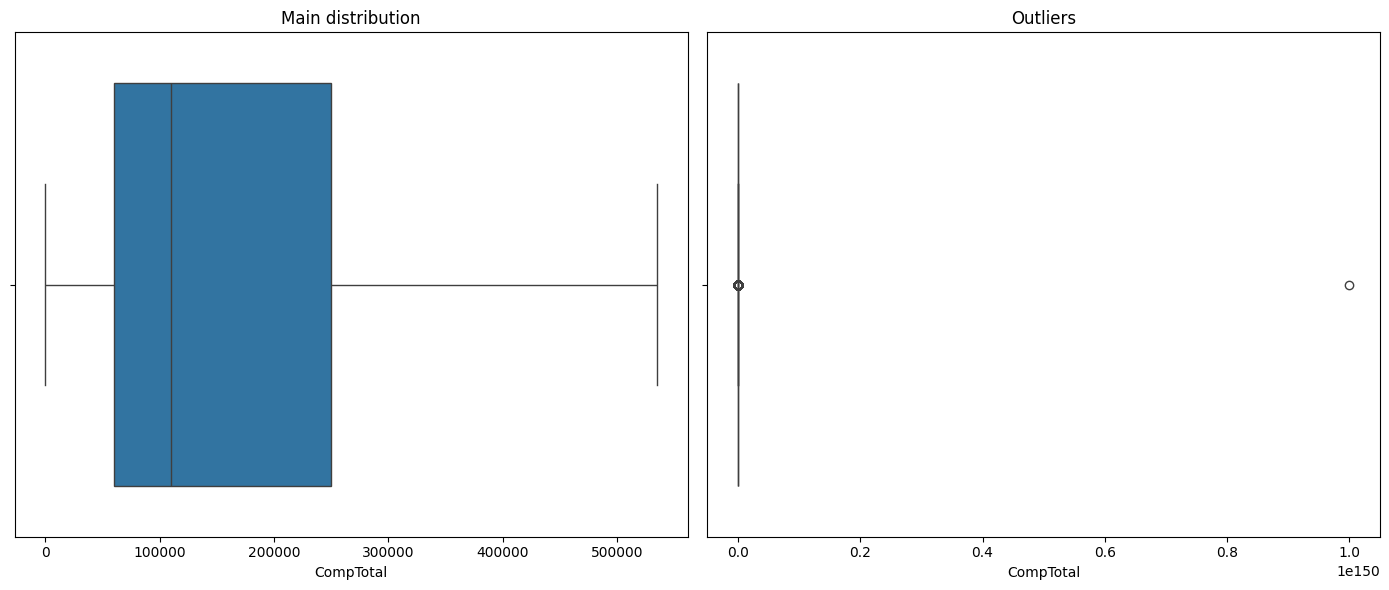

In [11]:

q1 = df['CompTotal'].quantile(0.25)
q3 = df['CompTotal'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.boxplot(df, x='CompTotal', showfliers=False, ax=axes[0])
axes[0].set_title('Main distribution')

sns.boxplot(x=df[df['CompTotal'] > upper]['CompTotal'], ax=axes[1])
axes[1].set_title('Outliers')
plt.tight_layout()
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [12]:
# your code goes here
q='''
SELECT Age
FROM main
'''
df=pd.read_sql_query(q, conn)

In [13]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [14]:
df.dropna(inplace=True)

Text(0.5, 1.0, 'Distribution of Age')

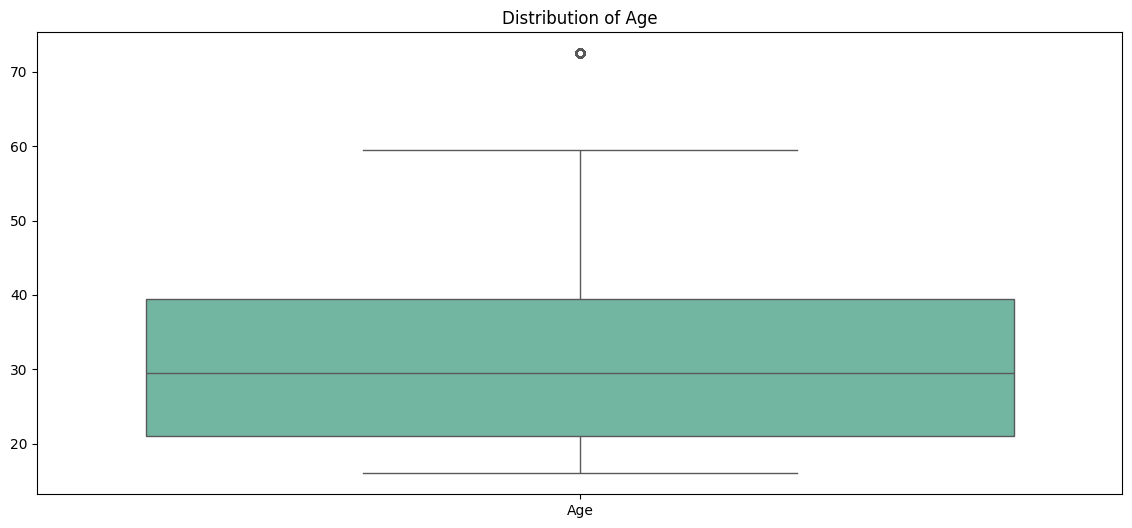

In [15]:
plt.figure(figsize=(14,6))
sns.boxplot(df, palette='Set2')
plt.title('Distribution of Age')

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [16]:
# your code goes here
q='''
SELECT Age, CompTotal
FROM main
'''
df=pd.read_sql_query(q, conn)

In [17]:
df.dropna(inplace=True)

In [18]:
df=df.reset_index(drop=True)

In [19]:
q1=df['CompTotal'].quantile(0.25)
q3=df['CompTotal'].quantile(0.75)
iqr=q3-q1
up=q3+1.5*iqr
out=df[df['CompTotal'] > up].index

In [20]:
df=df.drop(out)

In [21]:
df['CompTotal']=df['CompTotal'].drop(df[df['CompTotal'] == 0].index)

(-5000.0, 561749.95)

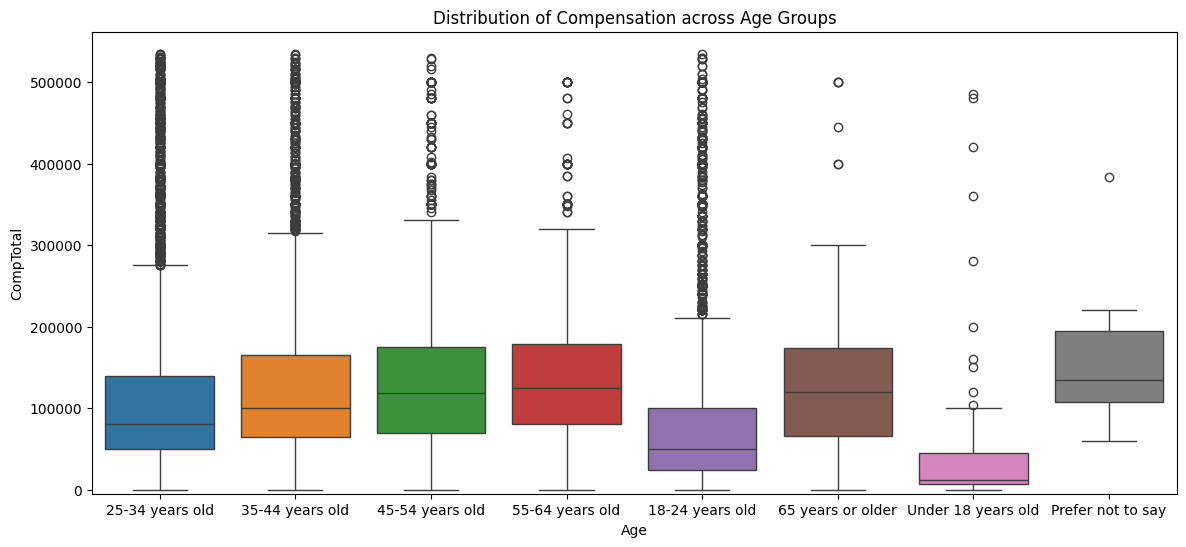

In [22]:
plt.figure(figsize=(14,6))
sns.boxplot(df, x='Age', y='CompTotal', hue='Age', legend=None)
plt.title('Distribution of Compensation across Age Groups')
plt.ylim(-5000,)

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [23]:
# your code goes here
q='''
SELECT CompTotal, JobSatPoints_6
FROM main
'''
df=pd.read_sql_query(q,conn)

In [24]:
q1=df['CompTotal'].quantile(0.25)
q3=df['CompTotal'].quantile(0.75)
iqr=q3-q1
up=q3+1.5*iqr
out=df[df['CompTotal'] > up].index
df=df.drop(out)

In [25]:
df.dropna(inplace=True)

In [26]:
bins=np.linspace(min(df['JobSatPoints_6']), max(df['JobSatPoints_6']), 11)
grn=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
df['JobSatPoints_6']=pd.cut(df['JobSatPoints_6'], bins, labels=grn, include_lowest=True)

In [27]:
df

,CompTotal,JobSatPoints_6
379,85000.0,0-10
389,110000.0,10-20
392,126420.0,20-30
398,195000.0,20-30
415,74000.0,20-30
...,...,...
65161,40000.0,10-20
65163,46000.0,40-50
65166,81600.0,10-20
65168,500000.0,0-10


Text(0.5, 1.0, 'Distribution of Total Compensation based on Job Satisfaction Levels')

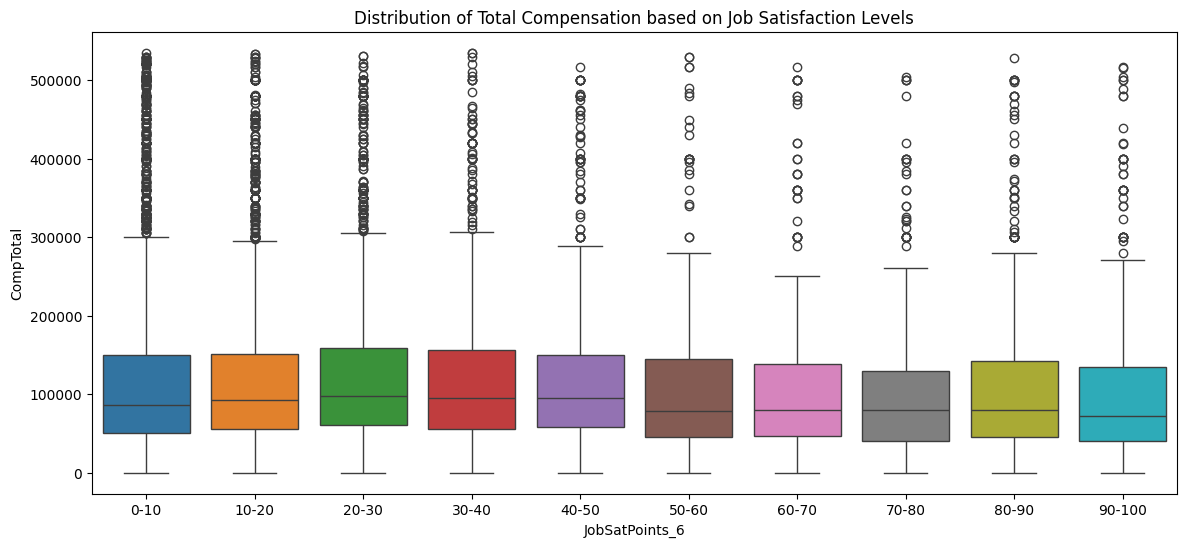

In [28]:
plt.figure(figsize=(14,6))
sns.boxplot(df, x='JobSatPoints_6', y='CompTotal', hue='JobSatPoints_6', legend=None)
plt.title('Distribution of Total Compensation based on Job Satisfaction Levels')

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [132]:
# your code goes here
q='''
SELECT ConvertedCompYearly, DevType
FROM main
'''
df=pd.read_sql_query(q, conn)

In [133]:
df.dropna(inplace=True)

In [134]:
upper=df['ConvertedCompYearly'].quantile(0.99)
out2=df[df['ConvertedCompYearly'] > upper].index
df=df.drop(out2)

In [145]:
val=df.groupby(['DevType']).sum().sort_values(by='ConvertedCompYearly', ascending=False).head().index

In [146]:
val

Index(['Developer, full-stack', 'Developer, back-end', 'Developer, front-end',
       'Developer, desktop or enterprise applications', 'Engineering manager'],
      dtype='object', name='DevType')

In [147]:
df=df[df['DevType'].isin(val)]

<Axes: xlabel='DevType', ylabel='ConvertedCompYearly'>

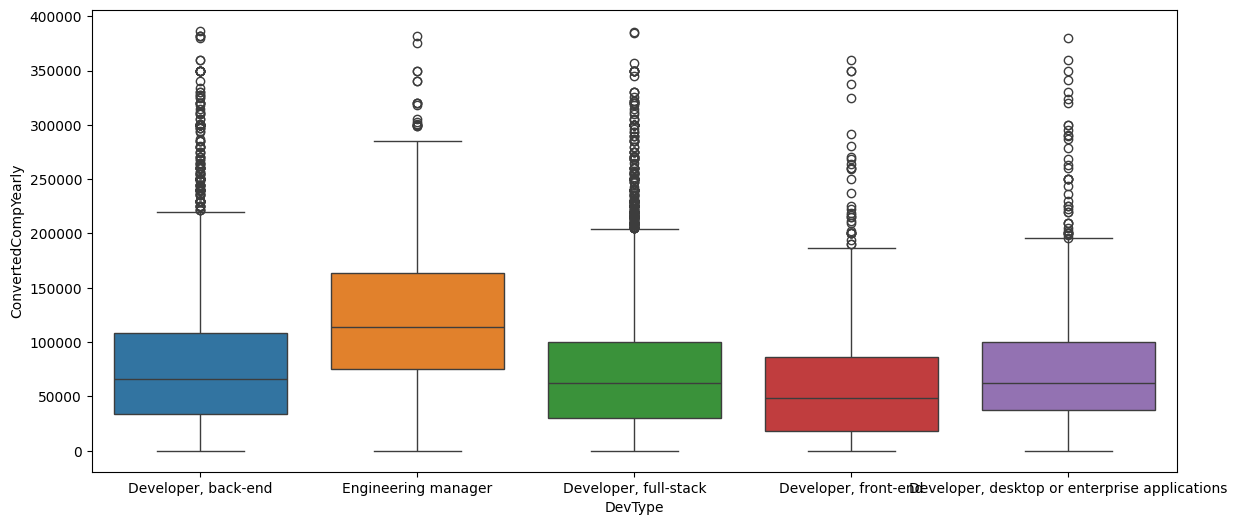

In [148]:
plt.figure(figsize=(14,6))
sns.boxplot(df, y='ConvertedCompYearly', x='DevType', hue='DevType')
#plt.ylim(-100000, 1750000)

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [267]:
q='''
SELECT Country, CompTotal
FROM main
'''
df=pd.read_sql_query(q,conn)

In [268]:
countries = [
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize",
    "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Brunei", "Bulgaria", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad",
    "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Côte d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
    "Denmark", "Djibouti", "Dominica", "Dominican Republic",
    "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia",
    "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France",
    "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada",
    "Guatemala", "Guinea", "Guinea-Bissau", "Guyana",
    "Haiti", "Honduras", "Hungary",
    "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy",
    "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan",
    "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg",
    "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta",
    "Marshall Islands", "Mauritania", "Mauritius", "Mexico", "Micronesia",
    "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua",
    "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway",
    "Oman",
    "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal",
    "Qatar",
    "Romania", "Russian Federation", "Rwanda",
    "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
    "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Solomon Islands", "Somalia", "South Africa", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom of Great Britain and Northern Ireland", "United States of America",
    "Uruguay", "Uzbekistan",
    "Vanuatu", "Vatican City", "Venezuela", "Vietnam",
    "Yemen",
    "Zambia", "Zimbabwe",
    "Holy See", "Palestine", 'kosovo', 'taiwan', 
]

df['Country'] = (
    df['Country']
    .astype(str)
    .str.strip()
    .str.lower()
)

all_countries_clean = [c.strip().lower() for c in countries]

new_list = {'iran, islamic republic of...' : 'iran',
             'republic of north macedonia' : 'macedonia',
             'united republic of tanzania' : 'tanzania',
             'viet nam' : 'vietnam',
             'venezuela, bolivarian republic of...': 'venezuela',
             'republic of korea' : 'south korea',
             'republic of moldova' : 'moldova', 
             'hong kong (s.a.r.)' : 'china', 
             "lao people's democratic republic" : 'laos', 
             'democratic republic of the congo' : 'congo', 
             'syrian arab republic' : 'syria',
             'swaziland' : 'eswatini', 
             "democratic people's republic of korea" : 'north korea',
             'congo, republic of the...' : 'congo', 
             'libyan arab jamahiriya' : 'lybia',
             'cape verde' : 'cabo verde', 
             'brunei darussalam' : 'brunei',
             'micronesia, federated states of...' : 'micronesia',
             'macedonia' : 'north macedonia',
            'united kingdom of great britain and northern ireland' : 'UK',
            'united states of america' : 'USA',
            'dominican republic' : 'dominica'
           }
invalid_countries = df.loc[~df['Country'].isin(all_countries_clean), 'Country']
df['Country'] = df['Country'].replace(new_list)

In [269]:
df['Country']=df['Country'].str.capitalize()

In [270]:
# your code goes here
df['Country'] = df['Country'].replace({'Usa': 'USA','Uk': 'UK'})

In [271]:
df.dropna(inplace=True)

In [272]:
q1=df['CompTotal'].quantile(0.25)
q3=df['CompTotal'].quantile(0.75)
iqr=q3-q1
up=q3+1.5*iqr
dow=q1-1.5*iqr
out=df[(df['CompTotal'] > up) | (df['CompTotal'] < dow)].index
df=df.drop(out)

In [273]:
val=df.groupby(['Country']).sum().sort_values(by='CompTotal', ascending=False).head().index

In [274]:
val

Index(['USA', 'Germany', 'Poland', 'Canada', 'UK'], dtype='object', name='Country')

In [275]:
df=df[df['Country'].isin(val)]

<Axes: xlabel='Country', ylabel='CompTotal'>

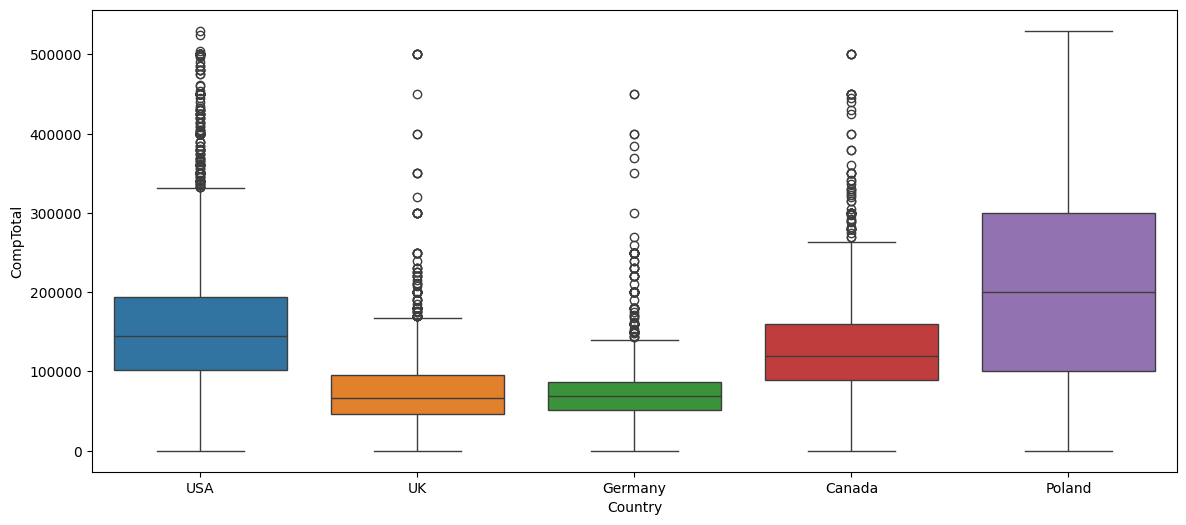

In [276]:
plt.figure(figsize=(14,6))
sns.boxplot(df, x='Country', y='CompTotal', hue='Country')

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [277]:
# your code goes here
q= '''
SELECT CompTotal, Employment
FROM main
'''
df=pd.read_sql_query(q,conn)

In [278]:
df.dropna(inplace=True)

In [280]:
df['Employment']=df['Employment'].str.split(';')
df=df.explode('Employment').reset_index(drop=True)
df

,CompTotal,Employment
0,2040000.0,"Employed, full-time"
1,2040000.0,"Student, full-time"
2,2040000.0,"Independent contractor, freelancer, or self-em..."
3,2040000.0,"Employed, part-time"
4,28000.0,"Employed, full-time"
...,...,...
39583,36000.0,"Independent contractor, freelancer, or self-em..."
39584,40000.0,"Employed, full-time"
39585,61000.0,"Employed, full-time"
39586,58000.0,"Employed, full-time"


In [283]:
q1=df['CompTotal'].quantile(0.25)
q3=df['CompTotal'].quantile(0.75)
iqr=q3-q1
up=q3+1.5*iqr
dow=q1-1.5*iqr
out=df[(df['CompTotal'] > up) | (df['CompTotal'] < dow)].index
df=df.drop(out)

Text(0.5, 1.0, 'Total Compensation across Employment Type')

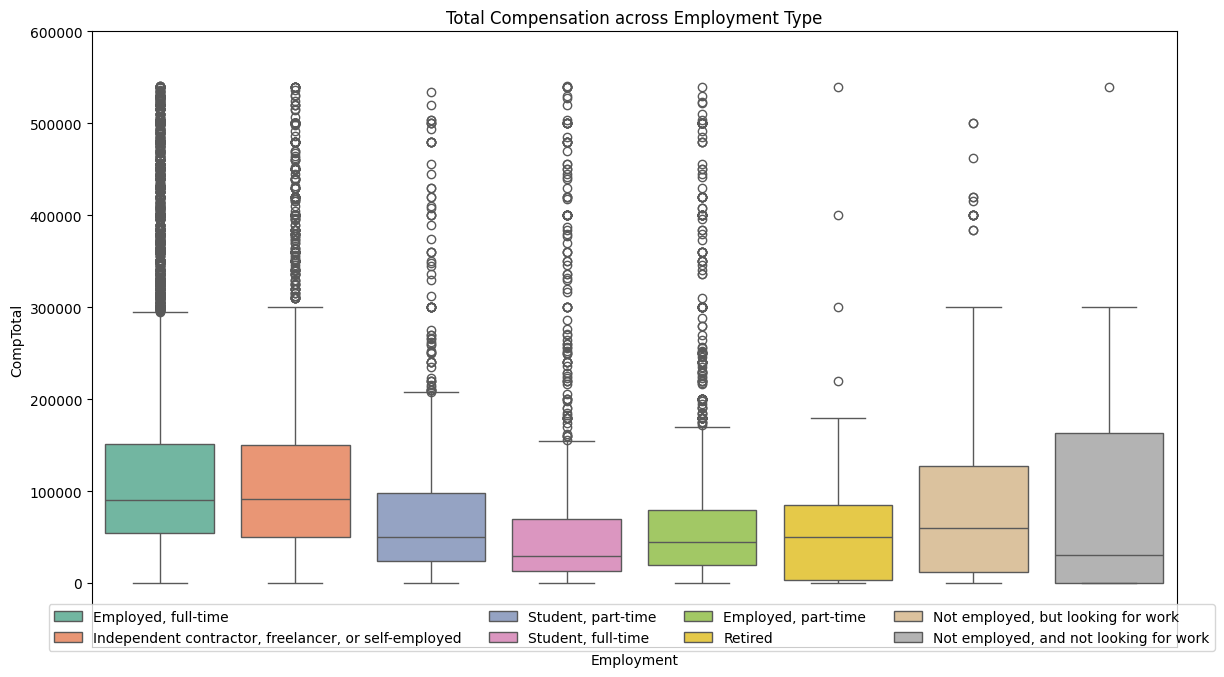

In [324]:
plt.figure(figsize=(14,8))
sns.boxplot(df, x='Employment', y='CompTotal', hue='Employment', legend='full', palette='Set2')
plt.ylim(-70000,600000)
plt.legend(loc=(-0.04,-0.005),ncol=4 )
plt.xticks([]);
plt.title('Total Compensation across Employment Type')

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


### Final Step: Close the Database Connection


In [325]:
# your code goes here
q='''
SELECT YearsCodePro, JobSatPoints_6
FROM main
'''
df=pd.read_sql_query(q,conn)

In [328]:
df.dropna(inplace=True)

In [334]:
df['YearsCodePro']=df['YearsCodePro'].replace({'Less than 1 year': 0.6, 'More than 50 years': 60})
df['YearsCodePro']=df['YearsCodePro'].astype(float)

In [335]:
bins=np.linspace(0, max(df['YearsCodePro']), 11)
grn=['0-6 Years', '6-12 Years', '12-18 Years', '18-24 Years', '24-30 Years', '30-36 Years', '36-42 Years', '42-48 Years', '48-54 Years', '54-60 Years']
df['YearsCodePro']=pd.cut(df['YearsCodePro'], bins, labels=grn, include_lowest=True)

Text(0.5, 1.0, 'Distribution of Professional Coding by Job Satisfaction Levels')

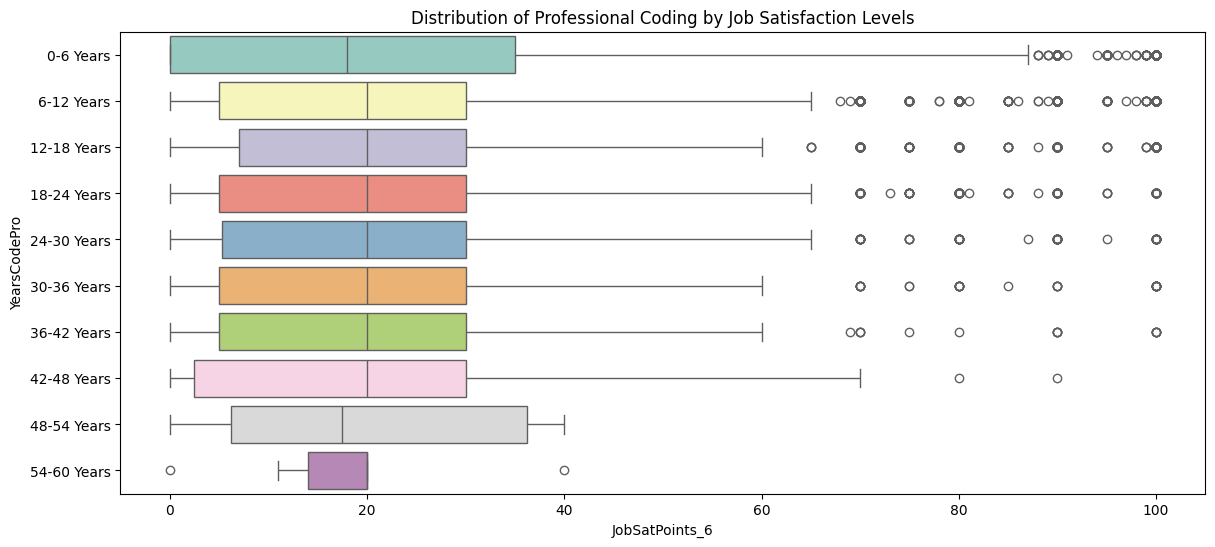

In [338]:
plt.figure(figsize=(14,6))
sns.boxplot(df, x='JobSatPoints_6', y='YearsCodePro', hue='YearsCodePro', palette='Set3')
plt.title('Distribution of Professional Coding by Job Satisfaction Levels')

After completing the lab, close the connection to the SQLite database:


In [339]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
